In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

from prophet import Prophet
import statsmodels.api as sm

import optuna
import warnings
warnings.filterwarnings("ignore")

BASE_PATH = Path(".")



Importing plotly failed. Interactive plots will not work.


In [2]:
def load_walmart_raw():
    train = pd.read_csv(BASE_PATH / "train.csv")
    features = pd.read_csv(BASE_PATH / "features.csv")
    stores = pd.read_csv(BASE_PATH / "stores.csv")

    train['Date'] = pd.to_datetime(train['Date'])
    features['Date'] = pd.to_datetime(features['Date'])

    df = (
        train.merge(features, on=['Store', 'Date'], how='left')
             .merge(stores, on='Store', how='left')
    )

    # Remove negative sales
    df = df[df['Weekly_Sales'] >= 0]

    # Fill numeric missing with median
    num_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    return df

raw_df = load_walmart_raw()
raw_df.head()


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [3]:
def build_weekly_series(df: pd.DataFrame) -> pd.DataFrame:
    weekly = (
        df
        .groupby('Date')
        .agg(
            Weekly_Sales=('Weekly_Sales', 'sum'),
            Temperature=('Temperature', 'mean'),
            Fuel_Price=('Fuel_Price', 'mean'),
            CPI=('CPI', 'mean'),
            Unemployment=('Unemployment', 'mean')
        )
        .reset_index()
        .sort_values('Date')
    )
    return weekly

weekly_df = build_weekly_series(raw_df)
weekly_df.head()


,Date,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment
0,2010-02-05,49750875.98,33.284630,2.717941,167.357048,8.578049
1,2010-02-12,48336800.10,33.370444,2.695955,167.401961,8.567855
2,2010-02-19,48277902.33,37.039727,2.673587,167.372455,8.574993
3,2010-02-26,43970440.65,38.636031,2.685449,167.724288,8.562098
4,2010-03-05,46872715.16,42.367490,2.731923,167.680036,8.573890


In [4]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['month'] = df['Date'].dt.month.astype(int)
    df['year'] = df['Date'].dt.year.astype(int)
    df['is_year_start'] = df['Date'].dt.is_year_start.astype(int)
    df['is_year_end']   = df['Date'].dt.is_year_end.astype(int)
    return df

def add_lag_features(df: pd.DataFrame, col: str = 'Weekly_Sales',
                     lags=(1, 2, 4, 8, 12)) -> pd.DataFrame:
    df = df.copy()
    for lag in lags:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    return df

def add_rolling_features(df: pd.DataFrame, col: str = 'Weekly_Sales',
                         windows=(4, 8, 12)) -> pd.DataFrame:
    df = df.copy()
    for w in windows:
        df[f'{col}_roll_mean_{w}'] = df[col].shift(1).rolling(w).mean()
        df[f'{col}_roll_std_{w}']  = df[col].shift(1).rolling(w).std()
    return df

feat_df = weekly_df.copy()
feat_df = add_time_features(feat_df)
feat_df = add_lag_features(feat_df)
feat_df = add_rolling_features(feat_df)

# Drop initial rows with NaNs from lags/rolling
feat_df = feat_df.dropna().reset_index(drop=True)
feat_df.head()


,Date,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,weekofyear,month,year,is_year_start,...,Weekly_Sales_lag_2,Weekly_Sales_lag_4,Weekly_Sales_lag_8,Weekly_Sales_lag_12,Weekly_Sales_roll_mean_4,Weekly_Sales_roll_std_4,Weekly_Sales_roll_mean_8,Weekly_Sales_roll_std_8,Weekly_Sales_roll_mean_12,Weekly_Sales_roll_std_12
0,2010-04-30,43706044.18,57.305901,2.891237,167.230656,8.448258,17,4,2010,0,...,45183702.69,50424232.22,46872715.16,49750875.98,4.692699e+07,2.599282e+06,4.620394e+07,2.022774e+06,4.666396e+07,2.185106e+06
1,2010-05-07,48503424.39,63.819540,2.931807,167.143464,8.454880,18,5,2010,0,...,44734552.03,47365466.31,45926841.32,48336800.10,4.524744e+07,1.541542e+06,4.580811e+07,2.177156e+06,4.616023e+07,2.104039e+06
2,2010-05-14,45330146.41,59.913605,2.946522,167.110671,8.453271,19,5,2010,0,...,43706044.18,45183702.69,44989431.42,48277902.33,4.553193e+07,2.075308e+06,4.613018e+07,2.378500e+06,4.617411e+07,2.120197e+06
3,2010-05-21,45120250.64,65.698206,2.923671,167.388721,8.449236,20,5,2010,0,...,48503424.39,44734552.03,44134583.50,43970440.65,4.556854e+07,2.068397e+06,4.617277e+07,2.358119e+06,4.592847e+07,2.022820e+06
4,2010-05-28,47757773.63,70.140514,2.866458,167.406570,8.450034,21,5,2010,0,...,45330146.41,43706044.18,50424232.22,46872715.16,4.566497e+07,2.025096e+06,4.629598e+07,2.260128e+06,4.602428e+07,1.947469e+06


In [5]:
def train_test_split_time(df: pd.DataFrame, test_size_ratio: float = 0.2):
    n = len(df)
    test_size = int(n * test_size_ratio)
    train_df = df.iloc[:-test_size]
    test_df  = df.iloc[-test_size:]
    return train_df, test_df

train_df, test_df = train_test_split_time(feat_df, test_size_ratio=0.2)

print(train_df['Date'].min(), "→", train_df['Date'].max())
print(test_df['Date'].min(),  "→", test_df['Date'].max())


2010-04-30 00:00:00 → 2012-04-27 00:00:00
2012-05-04 00:00:00 → 2012-10-26 00:00:00


In [6]:
def evaluate_forecast(y_true, y_pred, name="model"):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    mae = mean_absolute_error(y_true, y_pred)

    # ✓ Compute MSE manually without 'squared'
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    # ✓ Safe MAPE
    mape = (
        (np.abs((y_true - y_pred) / y_true))
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .mean() * 100
    )

    print(f"{name} → MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")

    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape}



In [7]:
def run_prophet_with_regressors(train_df, test_df):
    # Prepare data
    df_p = pd.concat([train_df, test_df], ignore_index=True)[
        ['Date', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
    ].rename(columns={"Date": "ds", "Weekly_Sales": "y"})

    train_mask = df_p['ds'] <= train_df['Date'].max()
    train_p = df_p[train_mask].copy()
    test_p  = df_p[~train_mask].copy()

    m = Prophet(weekly_seasonality=True, yearly_seasonality=True)
    for reg in ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']:
        m.add_regressor(reg)

    m.fit(train_p)

    forecast = m.predict(test_p[['ds', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']])
    y_true = test_p['y'].values
    y_pred = forecast['yhat'].values

    metrics = evaluate_forecast(y_true, y_pred, name="Prophet+Regressors")
    return metrics, forecast, m

prophet_metrics, prophet_forecast, prophet_model = run_prophet_with_regressors(train_df, test_df)


17:38:06 - cmdstanpy - INFO - Chain [1] start processing
17:38:06 - cmdstanpy - INFO - Chain [1] done processing


Prophet+Regressors → MAE: 2300820.60 | RMSE: 2748732.61 | MAPE: 4.95%


In [8]:
def run_sarimax(train_df, test_df, order=(1,1,1), seasonal_order=(1,1,1,52)):
    train = train_df.set_index('Date')
    test  = test_df.set_index('Date')

    y_train = train['Weekly_Sales']
    y_test  = test['Weekly_Sales']

    exog_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
    exog_train = train[exog_cols]
    exog_test  = test[exog_cols]

    model = sm.tsa.statespace.SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        exog=exog_train,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    results = model.fit(disp=False)

    y_pred = results.predict(start=test.index[0], end=test.index[-1], exog=exog_test)
    metrics = evaluate_forecast(y_test.values, y_pred.values, name="SARIMAX")

    return metrics, y_pred, results

sarimax_metrics, sarimax_pred, sarimax_model = run_sarimax(train_df, test_df)


SARIMAX → MAE: 3298371.70 | RMSE: 3629444.52 | MAPE: 7.09%


In [9]:
FEATURE_COLS = [
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'weekofyear', 'month', 'year', 'is_year_start', 'is_year_end'
] + [c for c in feat_df.columns if 'lag_' in c or 'roll_' in c]

TARGET_COL = 'Weekly_Sales'

def run_xgboost(train_df, test_df):
    X_train = train_df[FEATURE_COLS]
    y_train = train_df[TARGET_COL]
    X_test  = test_df[FEATURE_COLS]
    y_test  = test_df[TARGET_COL]

    model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = evaluate_forecast(y_test.values, y_pred, name="XGBoost")
    return metrics, y_pred, model

xgb_metrics, xgb_pred, xgb_model = run_xgboost(train_df, test_df)


XGBoost → MAE: 1221142.82 | RMSE: 1625766.07 | MAPE: 2.63%


In [10]:
metrics_list = [prophet_metrics, sarimax_metrics, xgb_metrics]
metrics_df = pd.DataFrame(metrics_list).sort_values('RMSE')
metrics_df


,model,MAE,RMSE,MAPE
2,XGBoost,1.221143e+06,1.625766e+06,2.633430
0,Prophet+Regressors,2.300821e+06,2.748733e+06,4.954361
1,SARIMAX,3.298372e+06,3.629445e+06,7.088737


In [11]:
def export_best_model_predictions(train_df, test_df,
                                  prophet_forecast, sarimax_pred, xgb_pred,
                                  metrics_df):
    best_model_name = metrics_df.iloc[0]['model']
    print("🏆 Best model:", best_model_name)

    test_dates = test_df['Date'].reset_index(drop=True)
    y_true = test_df['Weekly_Sales'].reset_index(drop=True)

    if best_model_name == "Prophet+Regressors":
        y_pred = prophet_forecast['yhat'].reset_index(drop=True)
    elif best_model_name == "SARIMAX":
        y_pred = pd.Series(sarimax_pred.values).reset_index(drop=True)
    else:
        y_pred = pd.Series(xgb_pred).reset_index(drop=True)

    out = pd.DataFrame({
        "Date": test_dates,
        "Actual_Weekly_Sales": y_true,
        "Predicted_Weekly_Sales": y_pred,
        "Model": best_model_name
    })

    out.to_csv("walmart_best_model_test_predictions.csv", index=False)
    print("✔ Exported walmart_best_model_test_predictions.csv")

    return out

best_pred_df = export_best_model_predictions(
    train_df, test_df,
    prophet_forecast, sarimax_pred, xgb_pred,
    metrics_df
)

best_pred_df.head()


🏆 Best model: XGBoost
✔ Exported walmart_best_model_test_predictions.csv


,Date,Actual_Weekly_Sales,Predicted_Weekly_Sales,Model
0,2012-05-04,47124459.51,46495020.0,XGBoost
1,2012-05-11,46926829.21,45716080.0,XGBoost
2,2012-05-18,46824854.84,46575388.0,XGBoost
3,2012-05-25,47892949.14,46967820.0,XGBoost
4,2012-06-01,48281966.93,48132824.0,XGBoost


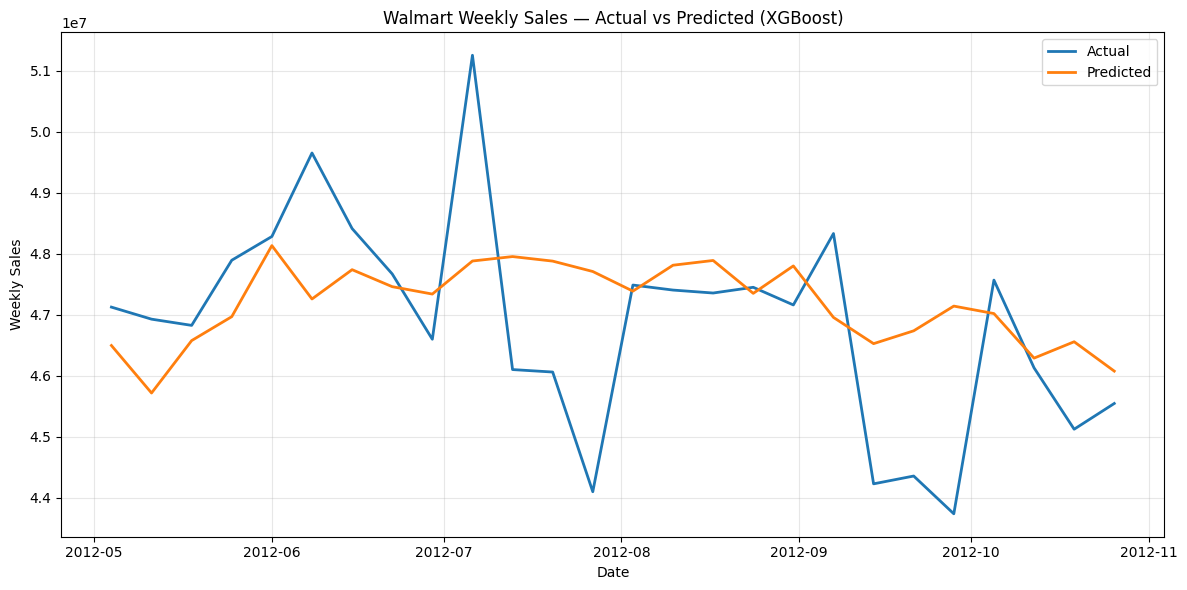

In [12]:
plt.figure(figsize=(12,6))
plt.plot(best_pred_df['Date'], best_pred_df['Actual_Weekly_Sales'], label='Actual', linewidth=2)
plt.plot(best_pred_df['Date'], best_pred_df['Predicted_Weekly_Sales'], label='Predicted', linewidth=2)
plt.title(f"Walmart Weekly Sales — Actual vs Predicted ({best_pred_df['Model'].iloc[0]})")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
import optuna

# Safe evaluation function (if not already defined)
def evaluate_forecast(y_true, y_pred, name="model"):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    mape = (
        (np.abs((y_true - y_pred) / y_true))
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .mean() * 100
    )

    print(f"{name} → MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")

    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape}


In [14]:
from prophet import Prophet
import optuna

from sklearn.model_selection import TimeSeriesSplit

FEATURE_COLS = [
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'weekofyear', 'month', 'year', 'is_year_start', 'is_year_end'
] + [c for c in feat_df.columns if 'lag_' in c or 'roll_' in c]

TARGET_COL = 'Weekly_Sales'

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
    }

    X = train_df[FEATURE_COLS].values
    y = train_df[TARGET_COL].values

    tscv = TimeSeriesSplit(n_splits=4)
    rmses = []

    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            tree_method="hist",
            **params
        )

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        # ✅ FIX HERE
        mse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(mse)

        rmses.append(rmse)

    return float(np.mean(rmses))



In [15]:
study_xgb = optuna.create_study(direction="minimize", study_name="xgb_walmart")
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

print("Best RMSE:", study_xgb.best_value)
print("Best params:")
study_xgb.best_params


[I 2025-12-10 17:38:08,916] A new study created in memory with name: xgb_walmart


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-10 17:38:09,719] Trial 0 finished with value: 6517811.474088877 and parameters: {'n_estimators': 252, 'learning_rate': 0.19578568478836503, 'max_depth': 4, 'min_child_weight': 8.213814052819389, 'subsample': 0.6943609141538956, 'colsample_bytree': 0.8321574760498802, 'gamma': 2.410748664476036, 'reg_lambda': 3.3464141792232347}. Best is trial 0 with value: 6517811.474088877.
[I 2025-12-10 17:38:10,828] Trial 1 finished with value: 6331575.127498069 and parameters: {'n_estimators': 400, 'learning_rate': 0.049100792946239, 'max_depth': 10, 'min_child_weight': 7.416623094083628, 'subsample': 0.689452287271219, 'colsample_bytree': 0.8136407075758599, 'gamma': 1.1080144599112014, 'reg_lambda': 1.5849598825632687}. Best is trial 1 with value: 6331575.127498069.
[I 2025-12-10 17:38:11,704] Trial 2 finished with value: 6607340.056830788 and parameters: {'n_estimators': 714, 'learning_rate': 0.1815732886902996, 'max_depth': 4, 'min_child_weight': 9.052437488675976, 'subsample': 0.640

{'n_estimators': 206,
 'learning_rate': 0.07927200683202838,
 'max_depth': 8,
 'min_child_weight': 2.536452986513993,
 'subsample': 0.8551886332774539,
 'colsample_bytree': 0.7746550585769839,
 'gamma': 3.6095439206652573,
 'reg_lambda': 3.856433794352867}

In [16]:
def objective_prophet(trial):

    # Hyperparameter search space
    params = {
        "changepoint_prior_scale": trial.suggest_float("changepoint_prior_scale", 0.001, 0.5, log=True),
        "seasonality_prior_scale": trial.suggest_float("seasonality_prior_scale", 0.1, 10),
        "seasonality_mode": trial.suggest_categorical("seasonality_mode", ["additive", "multiplicative"]),
        "weekly_seasonality": trial.suggest_categorical("weekly_seasonality", [True, False]),
        "yearly_seasonality": trial.suggest_categorical("yearly_seasonality", [True, False]),
    }

    # Prepare data
    df_p = train_df.rename(columns={"Date": "ds", "Weekly_Sales": "y"})[["ds", "y"]].copy()

    # Create model
    model = Prophet(
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"],
        weekly_seasonality=params["weekly_seasonality"],
        yearly_seasonality=params["yearly_seasonality"]
    )

    model.fit(df_p)

    # Forecast on the test set
    future = test_df.rename(columns={"Date": "ds"})[["ds"]]
    forecast = model.predict(future)

    y_true = test_df["Weekly_Sales"].values
    y_pred = forecast["yhat"].values

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return rmse  # Optuna minimizes this



In [17]:
study_prophet = optuna.create_study(direction="minimize", study_name="prophet_walmart")
study_prophet.optimize(objective_prophet, n_trials=30, show_progress_bar=True)

print("Best Prophet RMSE:", study_prophet.best_value)
print("Best Prophet Parameters:")
study_prophet.best_params


[I 2025-12-10 17:38:36,359] A new study created in memory with name: prophet_walmart


  0%|          | 0/30 [00:00<?, ?it/s]

17:38:36 - cmdstanpy - INFO - Chain [1] start processing
17:38:36 - cmdstanpy - INFO - Chain [1] done processing
17:38:36 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
17:38:36 - cmdstanpy - INFO - Chain [1] start processing
17:38:36 - cmdstanpy - INFO - Chain [1] done processing
17:38:36 - cmdstanpy - INFO - Chain [1] start processing
17:38:36 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:36,796] Trial 0 finished with value: 1410632.699688614 and parameters: {'changepoint_prior_scale': 0.0010588475203508686, 'seasonality_prior_scale': 6.345337370378742, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': False, 'yearly_seasonality': True}. Best is trial 0 with value: 1410632.699688614.
[I 2025-12-10 17:38:36,985] Trial 1 finished with value: 1375327.0715669012 and parameters: {'changepoint_prior_scale': 0.012557973794724083, 'seasonality_prior_scale': 5.6658458039747295, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 1 with value: 1375327.0715669012.


17:38:37 - cmdstanpy - INFO - Chain [1] start processing
17:38:37 - cmdstanpy - INFO - Chain [1] done processing
17:38:37 - cmdstanpy - INFO - Chain [1] start processing
17:38:37 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:37,170] Trial 2 finished with value: 1413694.7362327825 and parameters: {'changepoint_prior_scale': 0.01868942379505789, 'seasonality_prior_scale': 3.552263148528534, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 1 with value: 1375327.0715669012.
[I 2025-12-10 17:38:37,356] Trial 3 finished with value: 1358650.0873784658 and parameters: {'changepoint_prior_scale': 0.12957069911060876, 'seasonality_prior_scale': 4.426274530491676, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 3 with value: 1358650.0873784658.


17:38:37 - cmdstanpy - INFO - Chain [1] start processing
17:38:37 - cmdstanpy - INFO - Chain [1] done processing
17:38:37 - cmdstanpy - INFO - Chain [1] start processing
17:38:37 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:37,542] Trial 4 finished with value: 1412298.9758267277 and parameters: {'changepoint_prior_scale': 0.263908687917345, 'seasonality_prior_scale': 1.9893235739872681, 'seasonality_mode': 'additive', 'weekly_seasonality': False, 'yearly_seasonality': True}. Best is trial 3 with value: 1358650.0873784658.
[I 2025-12-10 17:38:37,699] Trial 5 finished with value: 2110116.919160833 and parameters: {'changepoint_prior_scale': 0.16810535987562322, 'seasonality_prior_scale': 4.284157948036498, 'seasonality_mode': 'additive', 'weekly_seasonality': False, 'yearly_seasonality': False}. Best is trial 3 with value: 1358650.0873784658.


17:38:37 - cmdstanpy - INFO - Chain [1] start processing
17:38:37 - cmdstanpy - INFO - Chain [1] done processing
17:38:37 - cmdstanpy - INFO - Chain [1] start processing
17:38:38 - cmdstanpy - INFO - Chain [1] done processing
17:38:38 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
17:38:38 - cmdstanpy - INFO - Chain [1] start processing


[I 2025-12-10 17:38:37,881] Trial 6 finished with value: 1365280.3147726355 and parameters: {'changepoint_prior_scale': 0.015566050671985411, 'seasonality_prior_scale': 3.406401400066469, 'seasonality_mode': 'additive', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 3 with value: 1358650.0873784658.


17:38:38 - cmdstanpy - INFO - Chain [1] done processing
17:38:38 - cmdstanpy - INFO - Chain [1] start processing
17:38:38 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:38,164] Trial 7 finished with value: 2208323.956305198 and parameters: {'changepoint_prior_scale': 0.0013264783324084502, 'seasonality_prior_scale': 1.4746868600460548, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': False, 'yearly_seasonality': False}. Best is trial 3 with value: 1358650.0873784658.
[I 2025-12-10 17:38:38,364] Trial 8 finished with value: 1946452.5257774012 and parameters: {'changepoint_prior_scale': 0.004840337600850772, 'seasonality_prior_scale': 8.567742849817067, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': False}. Best is trial 3 with value: 1358650.0873784658.


17:38:38 - cmdstanpy - INFO - Chain [1] start processing
17:38:38 - cmdstanpy - INFO - Chain [1] done processing
17:38:38 - cmdstanpy - INFO - Chain [1] start processing
17:38:38 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:38,580] Trial 9 finished with value: 1404523.682958203 and parameters: {'changepoint_prior_scale': 0.00889340337803871, 'seasonality_prior_scale': 1.487599182657614, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': False, 'yearly_seasonality': True}. Best is trial 3 with value: 1358650.0873784658.
[I 2025-12-10 17:38:38,794] Trial 10 finished with value: 2153849.776258408 and parameters: {'changepoint_prior_scale': 0.07246137818928916, 'seasonality_prior_scale': 8.01700978967055, 'seasonality_mode': 'additive', 'weekly_seasonality': True, 'yearly_seasonality': False}. Best is trial 3 with value: 1358650.0873784658.


17:38:38 - cmdstanpy - INFO - Chain [1] start processing
17:38:39 - cmdstanpy - INFO - Chain [1] done processing
17:38:39 - cmdstanpy - INFO - Chain [1] start processing
17:38:39 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:39,034] Trial 11 finished with value: 1387225.4620438279 and parameters: {'changepoint_prior_scale': 0.059633804152146086, 'seasonality_prior_scale': 3.421612440709495, 'seasonality_mode': 'additive', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 3 with value: 1358650.0873784658.


17:38:39 - cmdstanpy - INFO - Chain [1] start processing
17:38:39 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:39,245] Trial 12 finished with value: 1392609.7752403144 and parameters: {'changepoint_prior_scale': 0.05182543258222537, 'seasonality_prior_scale': 6.8387943142226515, 'seasonality_mode': 'additive', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 3 with value: 1358650.0873784658.
[I 2025-12-10 17:38:39,417] Trial 13 finished with value: 1437534.9433927431 and parameters: {'changepoint_prior_scale': 0.004633591411983543, 'seasonality_prior_scale': 2.944185714459858, 'seasonality_mode': 'additive', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 3 with value: 1358650.0873784658.


17:38:39 - cmdstanpy - INFO - Chain [1] start processing
17:38:39 - cmdstanpy - INFO - Chain [1] done processing
17:38:39 - cmdstanpy - INFO - Chain [1] start processing
17:38:39 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:39,658] Trial 14 finished with value: 1394359.731561579 and parameters: {'changepoint_prior_scale': 0.4978244980829735, 'seasonality_prior_scale': 4.7386515389243415, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 3 with value: 1358650.0873784658.
[I 2025-12-10 17:38:39,833] Trial 15 finished with value: 1355021.024847147 and parameters: {'changepoint_prior_scale': 0.032086741572012224, 'seasonality_prior_scale': 0.10947042571947474, 'seasonality_mode': 'additive', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 15 with value: 1355021.024847147.


17:38:39 - cmdstanpy - INFO - Chain [1] start processing
17:38:39 - cmdstanpy - INFO - Chain [1] done processing
17:38:40 - cmdstanpy - INFO - Chain [1] start processing
17:38:40 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:39,999] Trial 16 finished with value: 1362752.5524143213 and parameters: {'changepoint_prior_scale': 0.12627674922851795, 'seasonality_prior_scale': 0.6484797266987194, 'seasonality_mode': 'additive', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 15 with value: 1355021.024847147.
[I 2025-12-10 17:38:40,184] Trial 17 finished with value: 1355102.5691032307 and parameters: {'changepoint_prior_scale': 0.03289523360262638, 'seasonality_prior_scale': 0.1651240682936081, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 15 with value: 1355021.024847147.


17:38:40 - cmdstanpy - INFO - Chain [1] start processing
17:38:40 - cmdstanpy - INFO - Chain [1] done processing
17:38:40 - cmdstanpy - INFO - Chain [1] start processing
17:38:40 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:40,365] Trial 18 finished with value: 2027724.1416950256 and parameters: {'changepoint_prior_scale': 0.03346831018662313, 'seasonality_prior_scale': 0.2524378803618561, 'seasonality_mode': 'additive', 'weekly_seasonality': True, 'yearly_seasonality': False}. Best is trial 15 with value: 1355021.024847147.
[I 2025-12-10 17:38:40,544] Trial 19 finished with value: 1355321.9762882534 and parameters: {'changepoint_prior_scale': 0.02991165485659417, 'seasonality_prior_scale': 0.15287964569225032, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 15 with value: 1355021.024847147.


17:38:40 - cmdstanpy - INFO - Chain [1] start processing
17:38:40 - cmdstanpy - INFO - Chain [1] done processing
17:38:40 - cmdstanpy - INFO - Chain [1] start processing
17:38:40 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:40,727] Trial 20 finished with value: 1356915.2563025083 and parameters: {'changepoint_prior_scale': 0.006350862783440976, 'seasonality_prior_scale': 9.521146764423227, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 15 with value: 1355021.024847147.
[I 2025-12-10 17:38:40,915] Trial 21 finished with value: 1352138.0523235023 and parameters: {'changepoint_prior_scale': 0.026598240956584158, 'seasonality_prior_scale': 0.304802147514729, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 21 with value: 1352138.0523235023.


17:38:41 - cmdstanpy - INFO - Chain [1] start processing
17:38:41 - cmdstanpy - INFO - Chain [1] done processing
17:38:41 - cmdstanpy - INFO - Chain [1] start processing
17:38:41 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:41,111] Trial 22 finished with value: 1359904.1175884265 and parameters: {'changepoint_prior_scale': 0.037526647296566455, 'seasonality_prior_scale': 2.2104543751121857, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 21 with value: 1352138.0523235023.
[I 2025-12-10 17:38:41,306] Trial 23 finished with value: 1358294.2034474418 and parameters: {'changepoint_prior_scale': 0.002683103629049342, 'seasonality_prior_scale': 1.0088234741934032, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 21 with value: 1352138.0523235023.


17:38:41 - cmdstanpy - INFO - Chain [1] start processing
17:38:41 - cmdstanpy - INFO - Chain [1] done processing
17:38:41 - cmdstanpy - INFO - Chain [1] start processing
17:38:41 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:41,485] Trial 24 finished with value: 1466466.0561780266 and parameters: {'changepoint_prior_scale': 0.022938854136683614, 'seasonality_prior_scale': 2.0314612806658263, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 21 with value: 1352138.0523235023.
[I 2025-12-10 17:38:41,663] Trial 25 finished with value: 1373726.7858930116 and parameters: {'changepoint_prior_scale': 0.08044541114161398, 'seasonality_prior_scale': 0.9757240304576518, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 21 with value: 1352138.0523235023.


17:38:41 - cmdstanpy - INFO - Chain [1] start processing
17:38:41 - cmdstanpy - INFO - Chain [1] done processing
17:38:41 - cmdstanpy - INFO - Chain [1] start processing
17:38:41 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:41,824] Trial 26 finished with value: 1906027.0415438628 and parameters: {'changepoint_prior_scale': 0.01107873403864008, 'seasonality_prior_scale': 2.4254364074071626, 'seasonality_mode': 'additive', 'weekly_seasonality': False, 'yearly_seasonality': False}. Best is trial 21 with value: 1352138.0523235023.
[I 2025-12-10 17:38:42,021] Trial 27 finished with value: 1405948.5233493075 and parameters: {'changepoint_prior_scale': 0.022831367117063184, 'seasonality_prior_scale': 1.258623909501899, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 21 with value: 1352138.0523235023.


17:38:42 - cmdstanpy - INFO - Chain [1] start processing
17:38:42 - cmdstanpy - INFO - Chain [1] done processing
17:38:42 - cmdstanpy - INFO - Chain [1] start processing
17:38:42 - cmdstanpy - INFO - Chain [1] done processing


[I 2025-12-10 17:38:42,230] Trial 28 finished with value: 1380240.5963364595 and parameters: {'changepoint_prior_scale': 0.05513361622211999, 'seasonality_prior_scale': 0.3048697391098222, 'seasonality_mode': 'additive', 'weekly_seasonality': True, 'yearly_seasonality': True}. Best is trial 21 with value: 1352138.0523235023.
[I 2025-12-10 17:38:42,420] Trial 29 finished with value: 1359980.08622701 and parameters: {'changepoint_prior_scale': 0.039426292452238554, 'seasonality_prior_scale': 5.975838733498637, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': False, 'yearly_seasonality': True}. Best is trial 21 with value: 1352138.0523235023.
Best Prophet RMSE: 1352138.0523235023
Best Prophet Parameters:


{'changepoint_prior_scale': 0.026598240956584158,
 'seasonality_prior_scale': 0.304802147514729,
 'seasonality_mode': 'multiplicative',
 'weekly_seasonality': True,
 'yearly_seasonality': True}

In [18]:
from xgboost import XGBRegressor

# Get best parameters from Optuna
best_params = study_xgb.best_params

# Create tuned XGBoost model
best_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    **best_params
)

# Train using FULL training data
best_xgb.fit(train_df[FEATURE_COLS], train_df[TARGET_COL])


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7746550585769839
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [19]:
X_test = test_df[FEATURE_COLS]
y_test = test_df["Weekly_Sales"]
y_pred_test = best_xgb.predict(X_test)

xgb_opt_df = pd.DataFrame({
    "Date": test_df["Date"].reset_index(drop=True),
    "Actual": y_test.reset_index(drop=True),
    "Predicted": y_pred_test
})

xgb_opt_df.head()


,Date,Actual,Predicted
0,2012-05-04,47124459.51,45228924.0
1,2012-05-11,46926829.21,46131412.0
2,2012-05-18,46824854.84,45502812.0
3,2012-05-25,47892949.14,45639336.0
4,2012-06-01,48281966.93,47517312.0


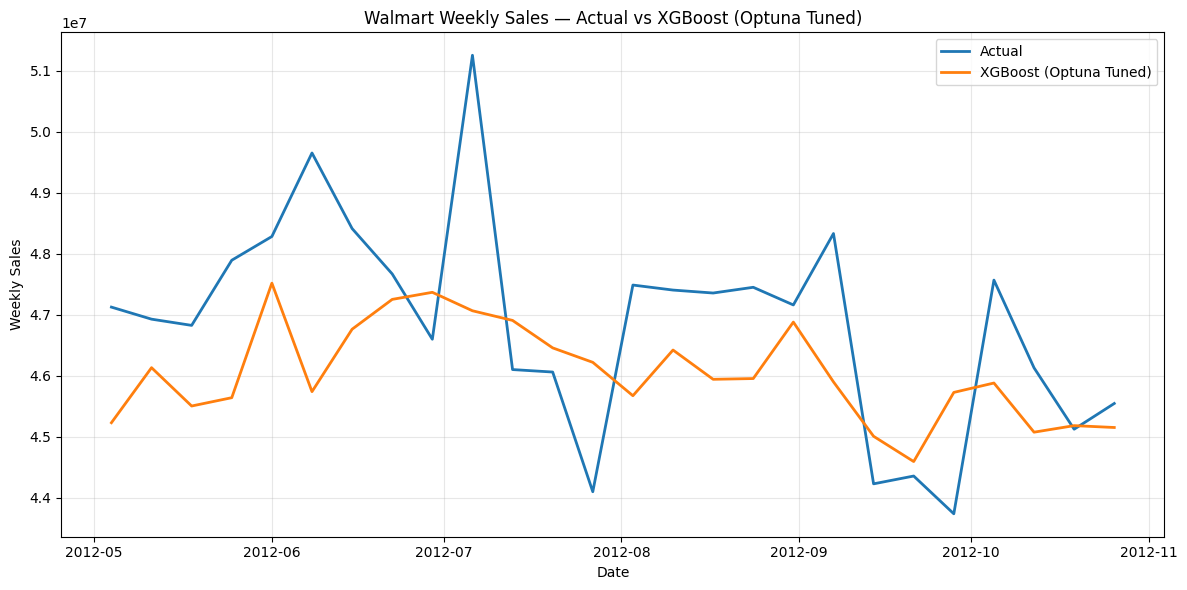

In [20]:
plt.figure(figsize=(12,6))

plt.plot(xgb_opt_df["Date"], xgb_opt_df["Actual"], label="Actual", linewidth=2)
plt.plot(xgb_opt_df["Date"], xgb_opt_df["Predicted"], label="XGBoost (Optuna Tuned)", linewidth=2)

plt.title("Walmart Weekly Sales — Actual vs XGBoost (Optuna Tuned)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
best_params = study_prophet.best_params

final_prophet = Prophet(
    changepoint_prior_scale=best_params["changepoint_prior_scale"],
    seasonality_prior_scale=best_params["seasonality_prior_scale"],
    seasonality_mode=best_params["seasonality_mode"],
    weekly_seasonality=best_params["weekly_seasonality"],
    yearly_seasonality=best_params["yearly_seasonality"]
)

df_p_train = train_df.rename(columns={"Date": "ds", "Weekly_Sales": "y"})[["ds", "y"]]
df_p_test = test_df.rename(columns={"Date": "ds"})

final_prophet.fit(df_p_train)

future = df_p_test[["ds"]]
forecast = final_prophet.predict(future)

y_true = test_df["Weekly_Sales"].values
y_pred = forecast["yhat"].values

prophet_metrics = evaluate_forecast(y_true, y_pred, "Prophet_Optuna")
prophet_metrics


17:38:43 - cmdstanpy - INFO - Chain [1] start processing
17:38:43 - cmdstanpy - INFO - Chain [1] done processing


Prophet_Optuna → MAE: 1024014.14 | RMSE: 1352138.05 | MAPE: 2.17%


{'model': 'Prophet_Optuna',
 'MAE': 1024014.139969377,
 'RMSE': np.float64(1352138.0523235023),
 'MAPE': np.float64(2.169548846791134)}

In [22]:
prophet_pred_df = pd.DataFrame({
    "Date": test_df["Date"].reset_index(drop=True),
    "Actual_Weekly_Sales": test_df["Weekly_Sales"].reset_index(drop=True),
    "Predicted_Weekly_Sales": y_pred,
    "Model": "Prophet_Optuna"
})

prophet_pred_df.to_csv("walmart_prophet_optuna_predictions.csv", index=False)
print("✔ Exported Prophet tuned predictions file")


✔ Exported Prophet tuned predictions file


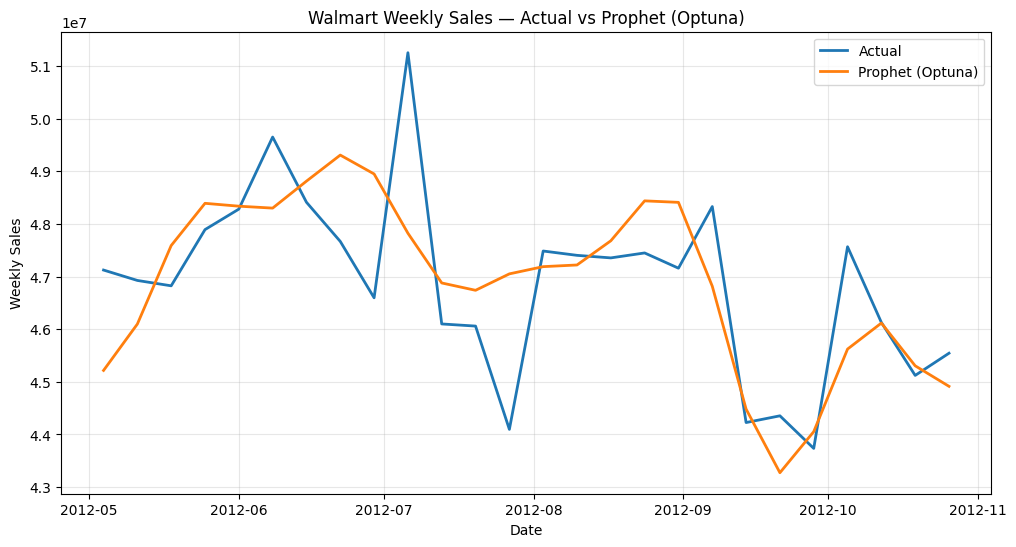

In [23]:
plt.figure(figsize=(12,6))
plt.plot(test_df["Date"], test_df["Weekly_Sales"], label="Actual", linewidth=2)
plt.plot(test_df["Date"], y_pred, label="Prophet (Optuna)", linewidth=2)
plt.title("Walmart Weekly Sales — Actual vs Prophet (Optuna)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [24]:
import numpy as np

# Make sure Date is datetime
train_df["Date"] = pd.to_datetime(train_df["Date"])
test_df["Date"] = pd.to_datetime(test_df["Date"])

# Work on the full timeline (train + test) to keep lags/rolling consistent
df_all = pd.concat([train_df, test_df], axis=0, ignore_index=True).sort_values("Date")

# ===== 1) Date encodings (balanced set) =====
df_all["weekofyear"] = df_all["Date"].dt.isocalendar().week.astype(int)
df_all["month"] = df_all["Date"].dt.month
df_all["quarter"] = df_all["Date"].dt.quarter
df_all["year"] = df_all["Date"].dt.year
df_all["is_year_start"] = df_all["Date"].dt.is_year_start.astype(int)
df_all["is_year_end"]   = df_all["Date"].dt.is_year_end.astype(int)
df_all["is_month_start"] = df_all["Date"].dt.is_month_start.astype(int)
df_all["is_month_end"]   = df_all["Date"].dt.is_month_end.astype(int)

# ===== 2) Lag features on Weekly_Sales =====
# Balanced set: short-term + medium + seasonal-ish
lag_list = [1, 2, 4, 12]  # 1 week, 2 weeks, 1 month, ~1 quarter
for lag in lag_list:
    df_all[f"lag_{lag}"] = df_all["Weekly_Sales"].shift(lag)

# ===== 3) Rolling statistics (shifted to avoid leakage) =====
# 4-week and 12-week windows
for window in [4, 12]:
    df_all[f"roll_mean_{window}"] = (
        df_all["Weekly_Sales"]
        .shift(1)                      # use only past values
        .rolling(window)
        .mean()
    )
    df_all[f"roll_std_{window}"] = (
        df_all["Weekly_Sales"]
        .shift(1)
        .rolling(window)
        .std()
    )

# ===== 4) Holiday-related features (if available) =====
if "IsHoliday" in df_all.columns:
    df_all["IsHoliday_flag"] = df_all["IsHoliday"].astype(int)
else:
    df_all["IsHoliday_flag"] = 0  # safe default if not present

# ===== 5) Simple interaction features (balanced, not too many) =====
df_all["fuel_temp"] = df_all["Fuel_Price"] * df_all["Temperature"]
df_all["cpi_unemp"] = df_all["CPI"] * df_all["Unemployment"]
df_all["lag_1_holiday"] = df_all["lag_1"] * df_all["IsHoliday_flag"]

# ===== 6) Drop initial rows with NaNs from lag/rolling =====
df_all = df_all.dropna().reset_index(drop=True)

print("Full feature-engineered df_all shape:", df_all.shape)
df_all.head()


Full feature-engineered df_all shape: (119, 37)


,Date,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,weekofyear,month,year,is_year_start,...,lag_4,lag_12,roll_mean_4,roll_std_4,roll_mean_12,roll_std_12,IsHoliday_flag,fuel_temp,cpi_unemp,lag_1_holiday
0,2010-07-23,44889146.07,80.696936,2.761544,167.662250,8.379981,29,7,2010,0,...,46609279.67,43706044.18,4.741773e+07,1.226692e+06,4.714385e+07,1.814319e+06,0,222.848157,1405.006555,0.0
1,2010-07-30,44631854.44,78.811871,2.766046,167.676486,8.385757,30,7,2010,0,...,48917953.47,48503424.39,4.698770e+07,1.780895e+06,4.724244e+07,1.633675e+06,0,217.997293,1406.094249,0.0
2,2010-08-06,48205253.28,79.553330,2.775075,167.868879,8.382901,31,8,2010,0,...,47899738.27,45330146.41,4.591618e+07,1.499582e+06,4.691981e+07,1.740789e+06,0,220.766447,1407.228130,0.0
3,2010-08-13,46464427.88,79.056258,2.806134,167.850423,8.389130,32,8,2010,0,...,46243964.08,45120250.64,4.599255e+07,1.635875e+06,4.715940e+07,1.699473e+06,0,221.842431,1408.119005,0.0
4,2010-08-20,47061664.12,78.954385,2.783133,167.847843,8.381579,33,8,2010,0,...,44889146.07,47757773.63,4.604767e+07,1.650814e+06,4.727142e+07,1.593868e+06,0,219.740524,1406.829973,0.0


In [25]:
# We lost some initial rows due to lags/rolling, so we need to rebuild train/test
# Rule: everything with Date < first test date -> train, rest -> test

first_test_date = test_df["Date"].min()

train_df_fe = df_all[df_all["Date"] < first_test_date].copy()
test_df_fe  = df_all[df_all["Date"] >= first_test_date].copy()

print("New train_df_fe shape:", train_df_fe.shape)
print("New test_df_fe shape :", test_df_fe.shape)

# Replace the old dataframes with the feature-engineered ones
train_df = train_df_fe
test_df = test_df_fe


New train_df_fe shape: (93, 37)
New test_df_fe shape : (26, 37)


In [26]:
TARGET_COL = "Weekly_Sales"

basic_features = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "weekofyear",
    "month",
    "quarter",
    "year",
    "is_year_start",
    "is_year_end",
    "is_month_start",
    "is_month_end",
    "IsHoliday_flag",
    "fuel_temp",
    "cpi_unemp",
]

lag_features   = [c for c in train_df.columns if c.startswith("lag_")]
roll_features  = [c for c in train_df.columns if c.startswith("roll_mean_") or c.startswith("roll_std_")]

FEATURE_COLS = basic_features + lag_features + roll_features

print("Number of features:", len(FEATURE_COLS))
FEATURE_COLS


Number of features: 24


['Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment',
 'weekofyear',
 'month',
 'quarter',
 'year',
 'is_year_start',
 'is_year_end',
 'is_month_start',
 'is_month_end',
 'IsHoliday_flag',
 'fuel_temp',
 'cpi_unemp',
 'lag_1',
 'lag_2',
 'lag_4',
 'lag_12',
 'lag_1_holiday',
 'roll_mean_4',
 'roll_std_4',
 'roll_mean_12',
 'roll_std_12']

In [27]:
X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]

X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET_COL]

best_xgb.fit(X_train, y_train)
y_pred_test = best_xgb.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("XGBoost (Optuna + FE) MAE :", mae)
print("XGBoost (Optuna + FE) RMSE:", rmse)


XGBoost (Optuna + FE) MAE : 1378264.9873076924
XGBoost (Optuna + FE) RMSE: 1884462.0844558992


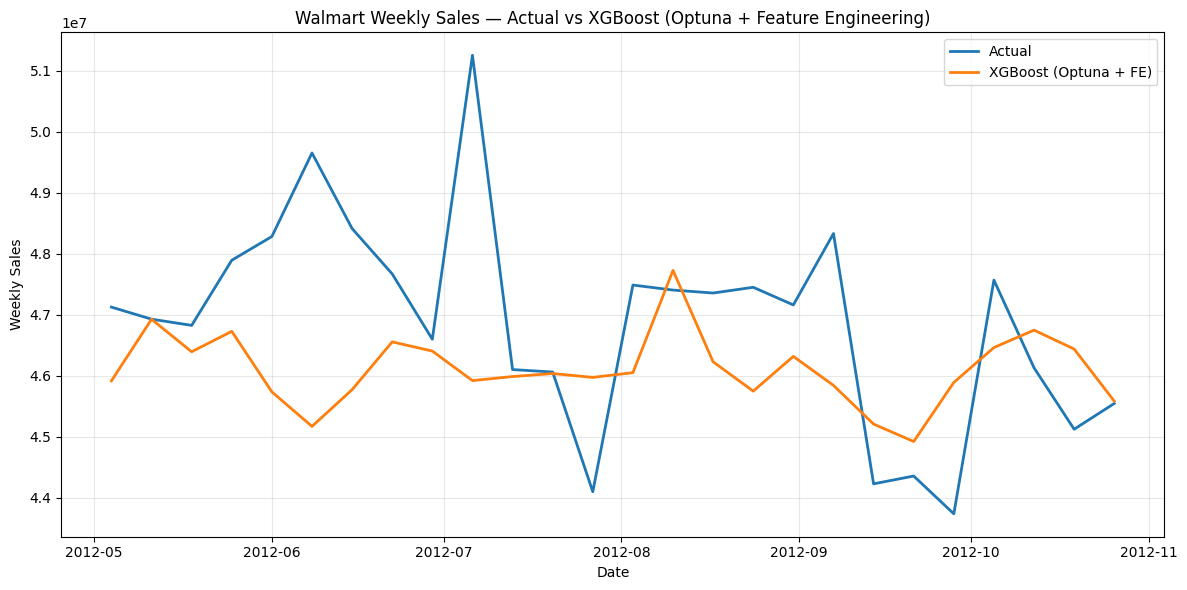

In [28]:
xgb_fe_df = pd.DataFrame({
    "Date": test_df["Date"].reset_index(drop=True),
    "Actual": y_test.reset_index(drop=True),
    "Predicted": y_pred_test
})

plt.figure(figsize=(12,6))
plt.plot(xgb_fe_df["Date"], xgb_fe_df["Actual"], label="Actual", linewidth=2)
plt.plot(xgb_fe_df["Date"], xgb_fe_df["Predicted"], label="XGBoost (Optuna + FE)", linewidth=2)
plt.title("Walmart Weekly Sales — Actual vs XGBoost (Optuna + Feature Engineering)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


[LOAD] clean_walmart.csv -> shape=(143, 2)
[LOAD] walmart_best_model_test_predictions.csv -> shape=(26, 4)
[LOAD] walmart_prophet_optuna_predictions.csv -> shape=(26, 4)
[LOAD] walmart_forecast.csv -> shape=(155, 19)
[INFO] clean_df date column = Date, sales column = Weekly_Sales
[INFO] XGB predictions standardized -> Date / Actual / Predicted
[INFO] Prophet predictions standardized -> Date / Predicted (+Actual if available)
[INFO] Future forecast standardized -> Date + predictions
=== Generating Walmart Forecasting Analytics Dashboard ===
[SAVED] dashboard_images\A_actual_vs_xgb.png


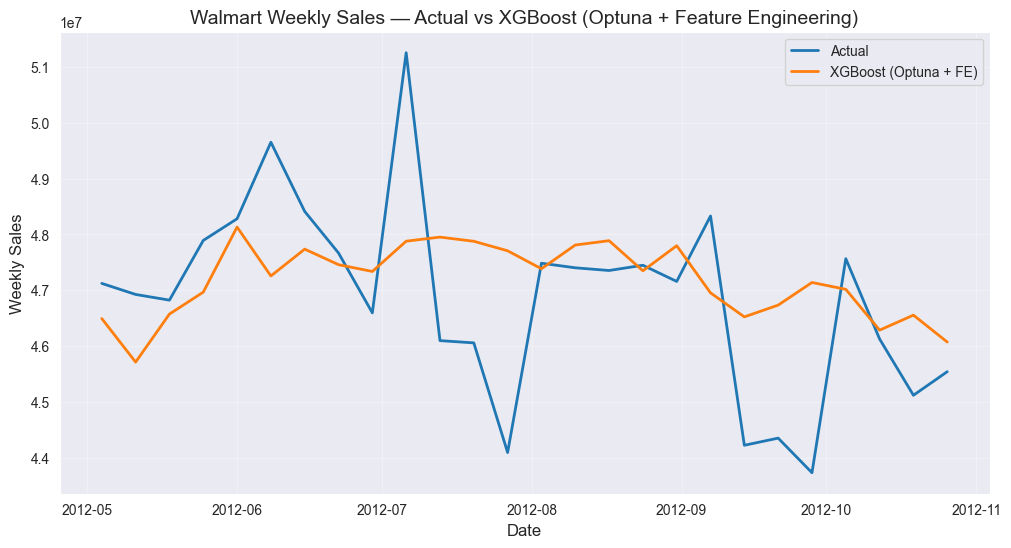

[SAVED] dashboard_images\B_actual_vs_prophet.png


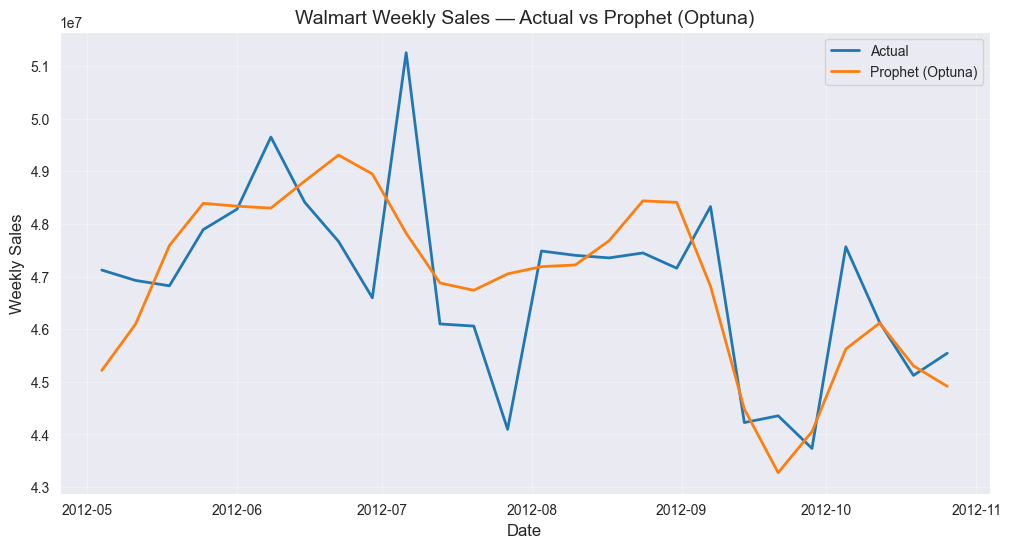

[SAVED] dashboard_images\C_model_comparison.png


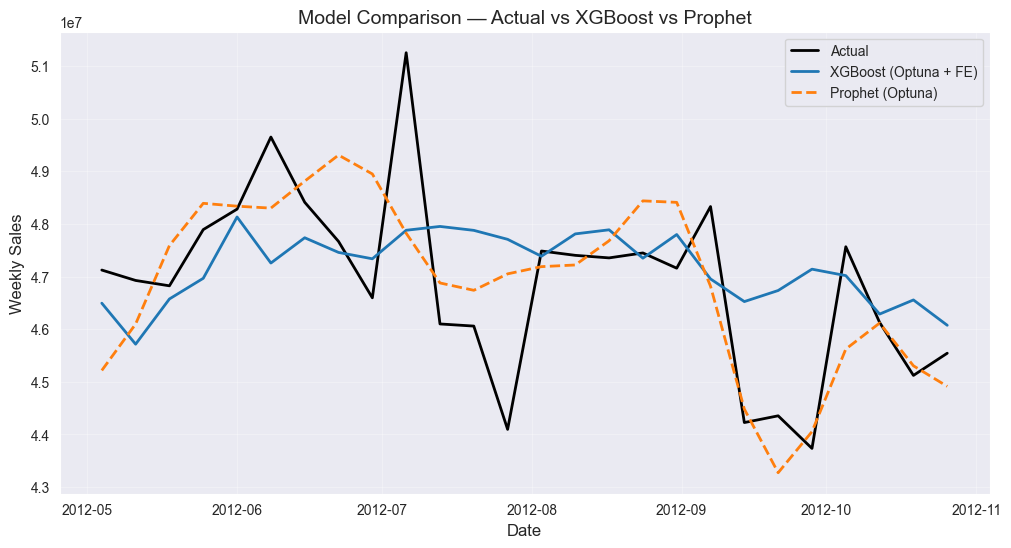

[SAVED] dashboard_images\D_residuals_over_time.png


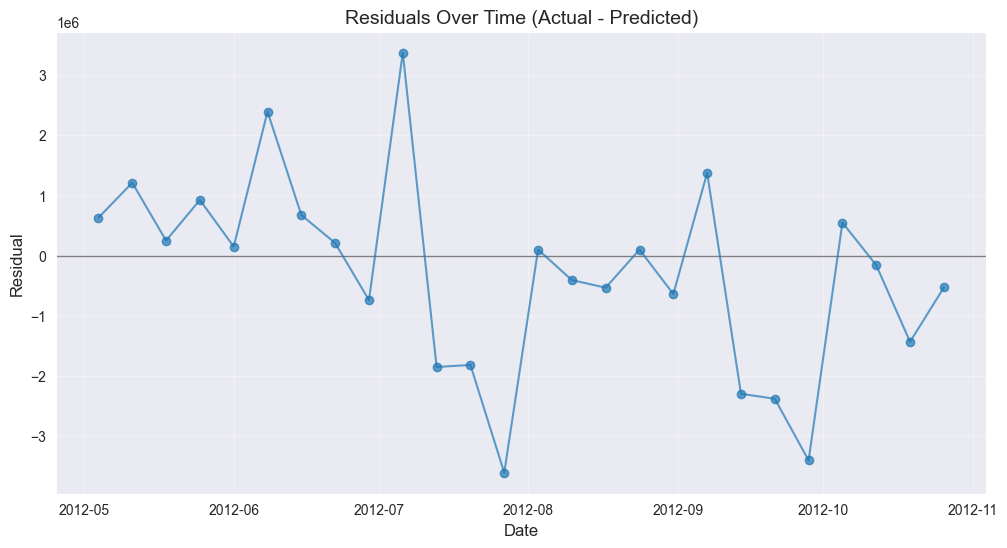

[SAVED] dashboard_images\E_residual_distribution.png


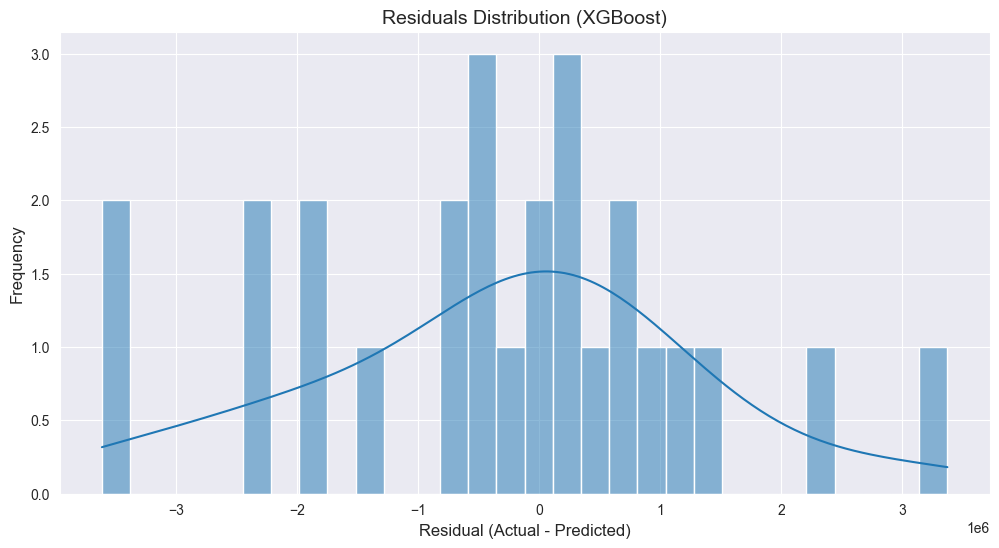

[SKIP] Feature importance not available: best_xgb model not found in globals().
[SAVED] dashboard_images\G_rolling_stats.png


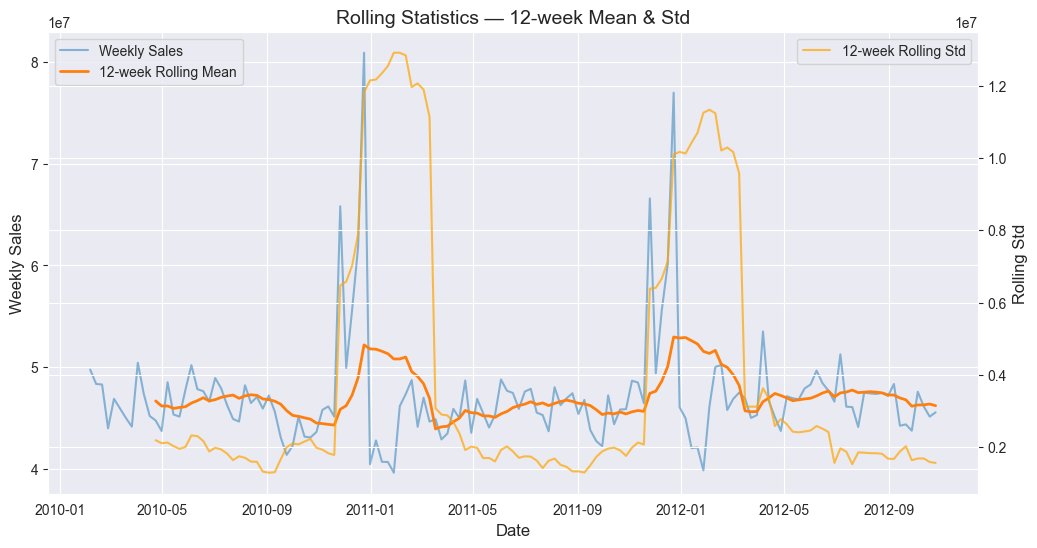

[SAVED] dashboard_images\H_seasonal_decomposition.png


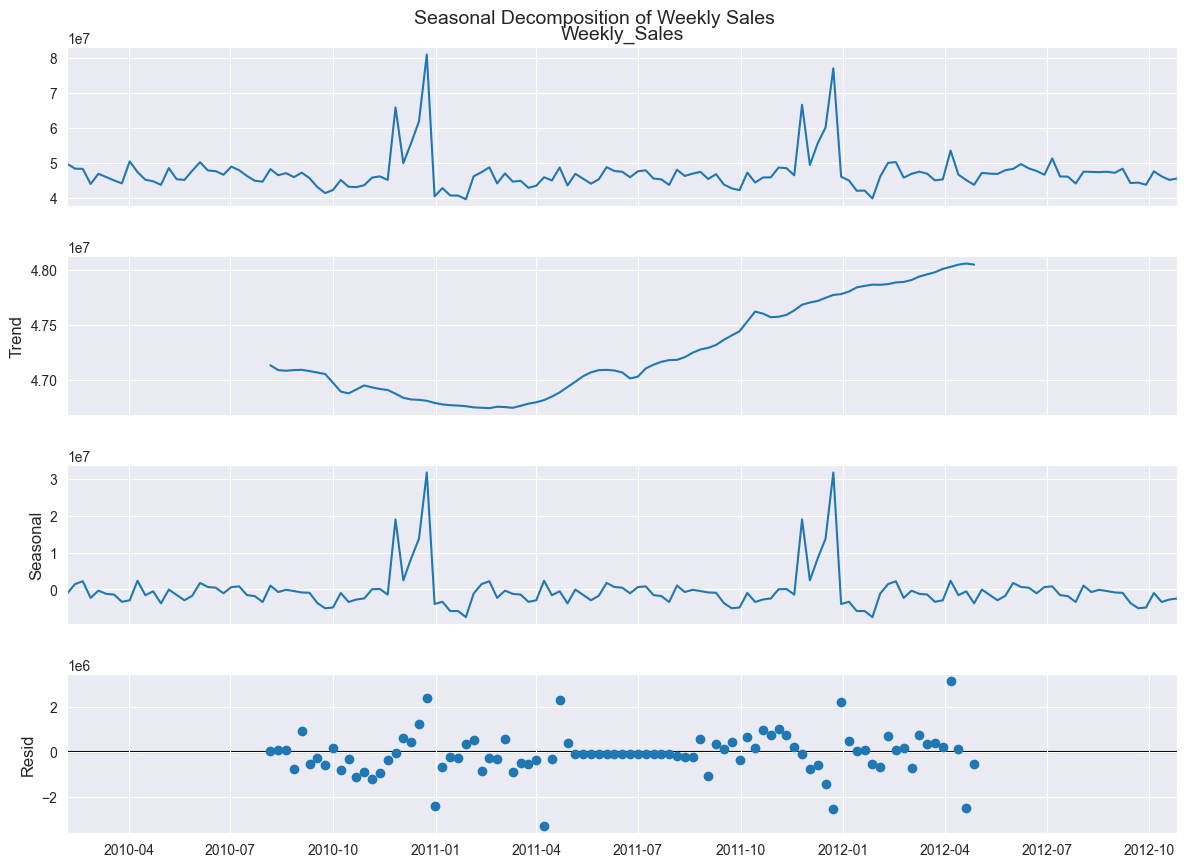

[INFO] Seasonal decomposition generated successfully!
[SAVED] dashboard_images\I_future_forecast.png


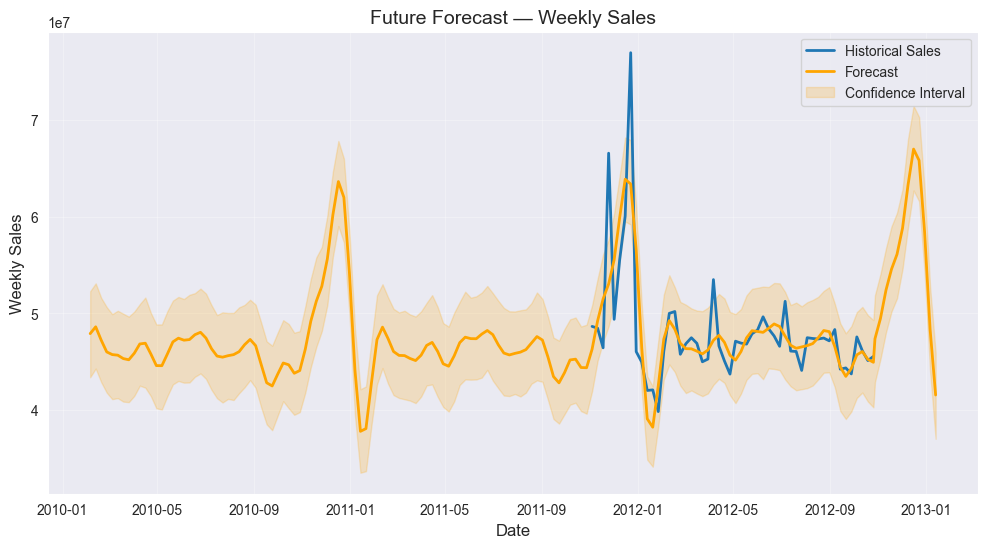

=== Dashboard generation complete. All images saved in 'dashboard_images/' ===


In [2]:
# WALMART FORECASTING ANALYTICS DASHBOARD (LEGENDARY EDITION)
# -----------------------------------------------------------
# Builds a complete forecasting analytics dashboard with:
# - Automatic column detection (date, sales, actual, predictions)
# - Robust cleaning & missing-value handling
# - Error-proof seasonal decomposition
# - Beautiful Matplotlib + Seaborn visualizations
# - All charts saved into ./dashboard_images/

import os
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from statsmodels.tsa.seasonal import seasonal_decompose
except ImportError:
    seasonal_decompose = None
    print("[WARN] statsmodels not installed – seasonal decomposition plots will be skipped.")

# ==========================
# 0. GLOBAL STYLE & OUTPUT DIR
# ==========================

OUTPUT_DIR = Path("dashboard_images")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


def save_fig(fig, name: str):
    """
    Save figure as a high-resolution PNG inside ./dashboard_images
    and show it inline.
    """
    filepath = OUTPUT_DIR / f"{name}.png"
    fig.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"[SAVED] {filepath}")
    plt.show()


# ==========================
# 1. SMART COLUMN DETECTION
# ==========================

def find_date_column(df: pd.DataFrame):
    """Find a date-like column (contains 'date' or is named 'ds')."""
    for col in df.columns:
        cname = col.lower()
        if "date" in cname or cname == "ds":
            return col
    raise ValueError("No date column found in dataframe.")


def find_sales_column(df: pd.DataFrame):
    """Find Weekly_Sales / Sales / last numeric column as fallback."""
    # Priority to 'Weekly_Sales' or containing 'sales'
    candidates = [c for c in df.columns if "weekly_sales" in c.lower() or c.lower() == "sales"]
    if candidates:
        return candidates[0]

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if not num_cols:
        raise ValueError("No numeric columns available to treat as sales.")
    return num_cols[-1]


def find_actual_column(df: pd.DataFrame):
    """Find actual values column in prediction files."""
    cand = [c for c in df.columns if "actual" in c.lower()]
    if cand:
        return cand[0]
    for col in df.columns:
        if "weekly_sales" in col.lower() or "sales" in col.lower():
            return col
    raise ValueError("No actual/Weekly_Sales column found in predictions df.")


def find_pred_column(df: pd.DataFrame):
    """Find prediction column (Predicted / yhat / forecast)."""
    cand = [c for c in df.columns if "pred" in c.lower() or "yhat" in c.lower() or "forecast" in c.lower()]
    if cand:
        return cand[0]
    raise ValueError("No predicted/yhat/forecast column found in predictions df.")


# ==========================
# 2. SAFE CSV LOADING
# ==========================

def load_csv_safe(path: str):
    if not Path(path).exists():
        print(f"[WARN] File not found: {path} – skipping.")
        return None
    df = pd.read_csv(path)
    print(f"[LOAD] {path} -> shape={df.shape}")
    return df


clean_df      = load_csv_safe("clean_walmart.csv")
xgb_pred_df   = load_csv_safe("walmart_best_model_test_predictions.csv")
prophet_df    = load_csv_safe("walmart_prophet_optuna_predictions.csv")
future_df     = load_csv_safe("walmart_forecast.csv")

# ==========================
# 3. STANDARDIZE STRUCTURES
# ==========================

date_col_clean = None
sales_col_clean = None
actual_col_prophet = None

# --- Clean main dataset ---
if clean_df is not None:
    date_col_clean = find_date_column(clean_df)
    clean_df[date_col_clean] = pd.to_datetime(clean_df[date_col_clean], errors="coerce")
    clean_df = clean_df.dropna(subset=[date_col_clean]).sort_values(date_col_clean)

    sales_col_clean = find_sales_column(clean_df)
    print(f"[INFO] clean_df date column = {date_col_clean}, sales column = {sales_col_clean}")

# --- XGBoost predictions ---
if xgb_pred_df is not None:
    dc = find_date_column(xgb_pred_df)
    xgb_pred_df[dc] = pd.to_datetime(xgb_pred_df[dc], errors="coerce")
    xgb_pred_df = xgb_pred_df.dropna(subset=[dc]).sort_values(dc)

    ac = find_actual_column(xgb_pred_df)
    pc = find_pred_column(xgb_pred_df)

    xgb_pred_df = xgb_pred_df.rename(columns={dc: "Date", ac: "Actual", pc: "Predicted"})
    print("[INFO] XGB predictions standardized -> Date / Actual / Predicted")

# --- Prophet predictions ---
if prophet_df is not None:
    dc = find_date_column(prophet_df)
    prophet_df[dc] = pd.to_datetime(prophet_df[dc], errors="coerce")
    prophet_df = prophet_df.dropna(subset=[dc]).sort_values(dc)

    # prediction column (yhat or similar)
    if "yhat" in prophet_df.columns:
        pc = "yhat"
    else:
        pc = find_pred_column(prophet_df)

    # actuals if exist
    if any("actual" in c.lower() for c in prophet_df.columns):
        actual_col_prophet = find_actual_column(prophet_df)

    rename_map = {dc: "Date", pc: "Predicted"}
    if actual_col_prophet is not None:
        rename_map[actual_col_prophet] = "Actual"

    prophet_df = prophet_df.rename(columns=rename_map)
    print("[INFO] Prophet predictions standardized -> Date / Predicted (+Actual if available)")

# --- Future forecast ---
if future_df is not None:
    dc = find_date_column(future_df)
    future_df[dc] = pd.to_datetime(future_df[dc], errors="coerce")
    future_df = future_df.dropna(subset=[dc]).sort_values(dc)
    future_df = future_df.rename(columns={dc: "Date"})
    print("[INFO] Future forecast standardized -> Date + predictions")


# ==========================
# 4. VISUALIZATION HELPERS
# ==========================

def build_residuals_df():
    if xgb_pred_df is None:
        return None
    df_res = xgb_pred_df.copy()
    df_res["Residual"] = df_res["Actual"] - df_res["Predicted"]
    return df_res


# ==========================
# 5. PLOTS
# ==========================

# A. Actual vs XGBoost
def plot_actual_vs_xgb():
    if xgb_pred_df is None:
        print("[SKIP] XGBoost predictions not available.")
        return

    fig, ax = plt.subplots()
    ax.plot(xgb_pred_df["Date"], xgb_pred_df["Actual"], label="Actual", linewidth=2)
    ax.plot(xgb_pred_df["Date"], xgb_pred_df["Predicted"], label="XGBoost (Optuna + FE)", linewidth=2)
    ax.set_title("Walmart Weekly Sales — Actual vs XGBoost (Optuna + Feature Engineering)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Weekly Sales")
    ax.legend()
    ax.grid(alpha=0.3)
    save_fig(fig, "A_actual_vs_xgb")


# B. Actual vs Prophet
def plot_actual_vs_prophet():
    if prophet_df is None:
        print("[SKIP] Prophet predictions not available.")
        return

    df_plot = prophet_df.copy()

    # Attach actuals from clean_df if not present
    if "Actual" not in df_plot.columns and clean_df is not None and date_col_clean is not None:
        df_clean_small = clean_df[[date_col_clean, sales_col_clean]].rename(
            columns={date_col_clean: "Date", sales_col_clean: "Actual"}
        )
        df_plot = df_plot.merge(df_clean_small, on="Date", how="left")

    if "Actual" not in df_plot.columns:
        print("[WARN] No actual column available for Prophet – plotting only predictions.")
        fig, ax = plt.subplots()
        ax.plot(df_plot["Date"], df_plot["Predicted"], label="Prophet (Optuna)", linewidth=2)
        ax.set_title("Prophet (Optuna) Forecast")
        ax.set_xlabel("Date")
        ax.set_ylabel("Weekly Sales")
        ax.legend()
        ax.grid(alpha=0.3)
        save_fig(fig, "B_prophet_predictions_only")
        return

    fig, ax = plt.subplots()
    ax.plot(df_plot["Date"], df_plot["Actual"], label="Actual", linewidth=2)
    ax.plot(df_plot["Date"], df_plot["Predicted"], label="Prophet (Optuna)", linewidth=2)
    ax.set_title("Walmart Weekly Sales — Actual vs Prophet (Optuna)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Weekly Sales")
    ax.legend()
    ax.grid(alpha=0.3)
    save_fig(fig, "B_actual_vs_prophet")


# C. Model comparison: Actual vs XGB vs Prophet
def plot_model_comparison():
    if xgb_pred_df is None or prophet_df is None:
        print("[SKIP] Cannot compare models – one of predictions is missing.")
        return

    df_x = xgb_pred_df[["Date", "Actual", "Predicted"]].rename(columns={"Predicted": "XGB_Pred"})
    df_p = prophet_df[["Date", "Predicted"]].rename(columns={"Predicted": "Prophet_Pred"})

    df_merge = df_x.merge(df_p, on="Date", how="inner")

    fig, ax = plt.subplots()
    ax.plot(df_merge["Date"], df_merge["Actual"], label="Actual", linewidth=2, color="black")
    ax.plot(df_merge["Date"], df_merge["XGB_Pred"], label="XGBoost (Optuna + FE)", linewidth=2)
    ax.plot(df_merge["Date"], df_merge["Prophet_Pred"], label="Prophet (Optuna)", linewidth=2, linestyle="--")
    ax.set_title("Model Comparison — Actual vs XGBoost vs Prophet")
    ax.set_xlabel("Date")
    ax.set_ylabel("Weekly Sales")
    ax.legend()
    ax.grid(alpha=0.3)
    save_fig(fig, "C_model_comparison")


# D. Residuals over time
def plot_residuals_over_time():
    df_res = build_residuals_df()
    if df_res is None:
        print("[SKIP] No residuals to plot.")
        return

    fig, ax = plt.subplots()
    ax.axhline(0, color="gray", linewidth=1)
    ax.plot(df_res["Date"], df_res["Residual"], marker="o", linestyle="-", alpha=0.7)
    ax.set_title("Residuals Over Time (Actual - Predicted)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Residual")
    ax.grid(alpha=0.3)
    save_fig(fig, "D_residuals_over_time")


# E. Residual distribution
def plot_residual_distribution():
    df_res = build_residuals_df()
    if df_res is None:
        print("[SKIP] No residuals to plot.")
        return

    fig, ax = plt.subplots()
    sns.histplot(df_res["Residual"], kde=True, ax=ax, bins=30)
    ax.set_title("Residuals Distribution (XGBoost)")
    ax.set_xlabel("Residual (Actual - Predicted)")
    ax.set_ylabel("Frequency")
    save_fig(fig, "E_residual_distribution")


# F. Feature importance (XGBoost)
def plot_feature_importance():
    try:
        # best_xgb should exist in the notebook; otherwise we skip gracefully
        if "best_xgb" not in globals():
            raise RuntimeError("best_xgb model not found in globals().")

        importances = best_xgb.feature_importances_
        # Try FEATURE_COLS, else generic names
        feature_names = globals().get("FEATURE_COLS", [f"feat_{i}" for i in range(len(importances))])

        fi_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
        fi_df = fi_df.sort_values("Importance", ascending=False).head(20)

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=fi_df, x="Importance", y="Feature", ax=ax)
        ax.set_title("Top 20 Feature Importances — XGBoost (Optuna + FE)")
        save_fig(fig, "F_feature_importance")
    except Exception as e:
        print(f"[SKIP] Feature importance not available: {e}")


# G. Rolling statistics (mean & std)
def plot_rolling_stats():
    if clean_df is None or date_col_clean is None or sales_col_clean is None:
        print("[SKIP] clean_walmart.csv not available or columns not detected.")
        return

    df = clean_df[[date_col_clean, sales_col_clean]].copy()
    df = df.sort_values(date_col_clean)
    df["roll_mean_12"] = df[sales_col_clean].rolling(12).mean()
    df["roll_std_12"] = df[sales_col_clean].rolling(12).std()

    fig, ax1 = plt.subplots()

    ax1.plot(df[date_col_clean], df[sales_col_clean], label="Weekly Sales", alpha=0.5)
    ax1.plot(df[date_col_clean], df["roll_mean_12"], label="12-week Rolling Mean", linewidth=2)
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Weekly Sales")
    ax1.legend(loc="upper left")

    ax2 = ax1.twinx()
    ax2.plot(df[date_col_clean], df["roll_std_12"], color="orange", label="12-week Rolling Std", alpha=0.7)
    ax2.set_ylabel("Rolling Std")
    ax2.legend(loc="upper right")

    plt.title("Rolling Statistics — 12-week Mean & Std")
    save_fig(fig, "G_rolling_stats")


# H. Seasonal decomposition (error-proof)
def plot_seasonal_decomposition():
    if seasonal_decompose is None:
        print("[SKIP] statsmodels not installed – cannot compute seasonal decomposition.")
        return
    if clean_df is None or date_col_clean is None or sales_col_clean is None:
        print("[SKIP] clean_walmart.csv not available for seasonal decomposition.")
        return

    df = clean_df[[date_col_clean, sales_col_clean]].copy()
    df = df.sort_values(date_col_clean).set_index(date_col_clean)

    # 1) Build perfect weekly index
    inferred = pd.infer_freq(df.index)
    freq = "W" if inferred is None else inferred
    full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)
    df = df.reindex(full_index)

    # 2) Clean series: numeric, no inf, no NaN
    s = df[sales_col_clean].astype(float)
    s = s.replace([np.inf, -np.inf], np.nan)
    s = s.interpolate(method="linear").bfill().ffill()

    if s.isna().any():
        print("[SKIP] Seasonal decomposition: still found NaNs after cleaning, skipping safely.")
        return

    # 3) Choose period (52 for weekly, fallback if too short)
    if len(s) >= 52 * 2:
        period = 52
    else:
        period = max(2, len(s) // 10)

    try:
        result = seasonal_decompose(s, model="additive", period=period)
    except Exception as e:
        print(f"[SKIP] Seasonal decomposition failed: {e}")
        return

    fig = result.plot()
    fig.set_size_inches(12, 9)
    fig.suptitle("Seasonal Decomposition of Weekly Sales", fontsize=14)
    save_fig(fig, "H_seasonal_decomposition")
    print("[INFO] Seasonal decomposition generated successfully!")


# I. Future forecast plot
def plot_future_forecast():
    if future_df is None:
        print("[SKIP] Future forecast not available.")
        return

    df_future = future_df.copy()

    # Identify main forecast + intervals
    y_cols = [c for c in df_future.columns if c.lower() in ("yhat", "forecast", "predicted")]
    lower_cols = [c for c in df_future.columns if "lower" in c.lower()]
    upper_cols = [c for c in df_future.columns if "upper" in c.lower()]

    if not y_cols:
        print("[SKIP] No yhat/forecast column in future_df.")
        return

    y_col = y_cols[0]
    y_lower = lower_cols[0] if lower_cols else None
    y_upper = upper_cols[0] if upper_cols else None

    fig, ax = plt.subplots()

    # Add recent history for context
    if clean_df is not None and date_col_clean is not None and sales_col_clean is not None:
        hist_tail = clean_df[[date_col_clean, sales_col_clean]].copy().rename(
            columns={date_col_clean: "Date", sales_col_clean: "Actual"}
        )
        hist_tail = hist_tail.sort_values("Date").tail(52)
        ax.plot(hist_tail["Date"], hist_tail["Actual"], label="Historical Sales", linewidth=2)

    ax.plot(df_future["Date"], df_future[y_col], label="Forecast", linewidth=2, color="orange")

    if y_lower is not None and y_upper is not None:
        ax.fill_between(
            df_future["Date"],
            df_future[y_lower],
            df_future[y_upper],
            color="orange",
            alpha=0.2,
            label="Confidence Interval"
        )

    ax.set_title("Future Forecast — Weekly Sales")
    ax.set_xlabel("Date")
    ax.set_ylabel("Weekly Sales")
    ax.legend()
    ax.grid(alpha=0.3)
    save_fig(fig, "I_future_forecast")


# ==========================
# 6. DASHBOARD EXPORTER
# ==========================

def export_dashboard():
    print("=== Generating Walmart Forecasting Analytics Dashboard ===")
    plot_actual_vs_xgb()
    plot_actual_vs_prophet()
    plot_model_comparison()
    plot_residuals_over_time()
    plot_residual_distribution()
    plot_feature_importance()
    plot_rolling_stats()
    plot_seasonal_decomposition()
    plot_future_forecast()
    print("=== Dashboard generation complete. All images saved in 'dashboard_images/' ===")


# Run everything
export_dashboard()


In [3]:
xgb_pred_df.to_csv("powerbi_xgb_predictions.csv", index=False)
print("✔ Exported: powerbi_xgb_predictions.csv")


✔ Exported: powerbi_xgb_predictions.csv


In [5]:
import pandas as pd

# Reload the Prophet predictions file you generated earlier
prophet_pred_df = pd.read_csv("walmart_prophet_optuna_predictions.csv")

# Make sure Date is datetime
prophet_pred_df['Date'] = pd.to_datetime(prophet_pred_df['Date'])

prophet_pred_df.head()


,Date,Actual_Weekly_Sales,Predicted_Weekly_Sales,Model
0,2012-05-04,47124459.51,4.521719e+07,Prophet_Optuna
1,2012-05-11,46926829.21,4.609878e+07,Prophet_Optuna
2,2012-05-18,46824854.84,4.758983e+07,Prophet_Optuna
3,2012-05-25,47892949.14,4.839233e+07,Prophet_Optuna
4,2012-06-01,48281966.93,4.833790e+07,Prophet_Optuna


In [6]:
prophet_pred_df.to_csv("powerbi_prophet_predictions.csv", index=False)
print("✔ Exported: powerbi_prophet_predictions.csv")


✔ Exported: powerbi_prophet_predictions.csv


In [7]:
future_df.to_csv("powerbi_future_forecast.csv", index=False)
print("✔ Exported: powerbi_future_forecast.csv")


✔ Exported: powerbi_future_forecast.csv


In [8]:
clean_df = pd.read_csv("clean_walmart.csv")
clean_df['Date'] = pd.to_datetime(clean_df['Date'])

clean_df.to_csv("powerbi_clean_walmart.csv", index=False)
print("✔ Exported: powerbi_clean_walmart.csv")


✔ Exported: powerbi_clean_walmart.csv
